# T-REMD → MBAR → 重み付きリサンプリング

このチュートリアルは、**Temperature-REMD (T-REMD)** で得た多状態サンプリングを **MBAR** で目標温度に再重み付けし、その重みで**重複ありリサンプリング**して「uniform weight で目標アンサンブルを近似する 1 本の通常トラジェクトリ」を生成するまでを、一気通貫で解説します。

生成したトラジェクトリは通常の MD 軌道と同じように扱えるため（ヒストグラム化・データベース登録など）、拡張サンプリングの結果を下流のパイプラインへそのまま渡せるのが利点です。

## 流れ

1. **データの理解** — トリアラニン (Ala3, 溶質 42 原子)、20 温度 (300.00〜351.26 K)、各 5000 フレーム
2. **通常の MBAR (自由エネルギー)** — 各温度状態の相対自由エネルギー `fene` を計算しリファレンスと照合
3. **重み (weight) の理解** — `return_weights=True` で目標温度 300 K における各サンプルの重みを取得
4. **重みによる再重み付け Ramachandran PMF** — φ/ψ を weight で重み付けし 300 K の自由エネルギー面を作成
5. **リサンプリング** — 重みに従って重複ありサンプリングし、uniform-weight のトラジェクトリを生成 → 素の φ/ψ ヒストグラムが手順 4 の PMF を再現することを確認
6. **保存・応用** — DCD として書き出し、下流パイプラインへ

> データは Google Drive から `gdown` でオンデマンド取得します（リポジトリにはコミットされていません）。

## 0. 準備: データのダウンロード

T-REMD チュートリアルデータ一式（約 50 MB）を取得します。初回のみダウンロードが走り、以降はスキップされます。

In [1]:
from genepie.tests import download_tremd_data

rc = download_tremd_data.download()
assert rc == 0 and download_tremd_data.is_available(), \
    "T-REMD data unavailable. Ensure gdown is installed: pip install gdown"
print("T-REMD tutorial data is ready.")

[SKIP] remd_alat_tutorial (already extracted at /Users/yasu/tmp/genepie/src/genepie/tests/data/remd_alat_tutorial)
T-REMD tutorial data is ready.


## 1. データの理解

使うのは **トリアラニン (Ala3)** の T-REMD です。生データを `remd_convert` で**温度（パラメータ）ソート**し、各温度状態ごとに以下を用意してあります。

| ファイル | 内容 |
|--------|------|
| `remd_paramID{k}.pot` | 状態 `k` の位置エネルギー時系列（`time value`）= MBAR の cvfile |
| `remd_paramID{k}_trialanine.dcd` | 状態 `k` の溶質（42 原子）のトラジェクトリ |
| `trialanine.pdb` / `ala3.psf` | トポロジー |
| `reference/` | 論文で得られた MBAR 参照結果（`fene.dat`・`weight{k}.dat`・`remd_paramID{k}.tor`） |

ポイント: `.pot` の行数（エネルギー出力数）と DCD のフレーム数は **1:1** で対応します（本データは各 5000 で一致）。

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from genepie.tests import conftest as C

NREPLICA = C.TREMD_NREPLICA
TEMPERATURES = C.TREMD_TEMPERATURES
TARGET_T = C.TREMD_TARGET_TEMPERATURE

print(f"replicas        : {NREPLICA}")
print(f"temperatures (K): {TEMPERATURES[0]:.2f} ... {TEMPERATURES[-1]:.2f}")
print(f"target T (K)    : {TARGET_T}")
print(f"cvfile pattern  : {C.TREMD_POT_PATTERN}")
print(f"dcd pattern     : {C.TREMD_DCD_PATTERN}")

# One state's potential-energy series (samples per state).
pot0 = np.loadtxt(C.TREMD_POT_PATTERN.format(1))
n_step = pot0.shape[0]
print(f"\nsamples per state: {n_step}  (total = {n_step * NREPLICA})")

replicas        : 20
temperatures (K): 300.00 ... 351.26
target T (K)    : 300.0
cvfile pattern  : /Users/yasu/tmp/genepie/src/genepie/tests/data/remd_alat_tutorial/remd_paramID{}.pot
dcd pattern     : /Users/yasu/tmp/genepie/src/genepie/tests/data/remd_alat_tutorial/remd_paramID{}_trialanine.dcd

samples per state: 5000  (total = 100000)


In [3]:
from genepie.s_molecule import SMolecule

mol = SMolecule.from_file(pdb=str(C.TREMD_PDB), psf=str(C.TREMD_PSF), ref=str(C.TREMD_PDB))
print(f"solute atoms: {mol.num_atoms}")

solute atoms: 42


## 2. 通常の MBAR（自由エネルギー）

MBAR は、異なる温度（状態）で取ったサンプルを**統合**して、各状態の相対自由エネルギーを推定します。T-REMD では `input_type="EneSingle"`（Fortran 内部で `REMD` と等価）に、温度リストと `target_temperature` を渡します。

> MBAR ソルバは Fortran のグローバル状態を保持するため、繰り返し呼ぶとクラッシュしやすいので、`mbar_analysis_isolated`（サブプロセス隔離版）を使います。

In [4]:
from genepie import genesis_exe

result = genesis_exe.mbar_analysis_isolated(
    cvfile=C.TREMD_POT_PATTERN,
    nreplica=NREPLICA,
    input_type="EneSingle",
    dimension=1,
    temperature=TEMPERATURES,
    target_temperature=TARGET_T,
    tolerance=1e-8,
    self_iteration=100,
    newton_iteration=10,
    return_weights=True,   # fene に加えて per-sample weight も取得
    timeout=600.0,
)

fene = result.fene[:, 0]   # shape (nreplica,)
print("relative free energy per state (kcal/mol):")
print(fene)

relative free energy per state (kcal/mol):
[   0.          537.96970992 1071.73471151 1595.15093748 2114.44268476
 2627.59564035 3132.75588531 3633.82321227 4127.06941677 4614.44691292
 5095.99056543 5570.0078454  6040.0454499  6504.4071523  6961.5199823
 7414.73675296 7860.8632616  8303.11695654 8738.42350076 9160.96438077]


max |fene - reference| = 1.22e-10


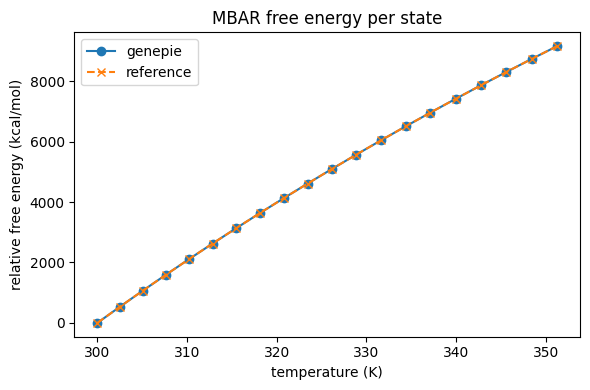

In [5]:
# Compare with the paper reference fene.dat.
fene_ref = np.loadtxt(str(C.TREMD_FENE_REF))
max_abs_err = np.max(np.abs(fene - fene_ref))
print(f"max |fene - reference| = {max_abs_err:.2e}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(TEMPERATURES, fene, "o-", label="genepie")
ax.plot(TEMPERATURES, fene_ref, "x--", label="reference")
ax.set_xlabel("temperature (K)")
ax.set_ylabel("relative free energy (kcal/mol)")
ax.set_title("MBAR free energy per state")
ax.legend()
plt.tight_layout()
plt.show()

## 3. 重み (weight) の理解

`return_weights=True` にすると、**目標温度 300 K** における各サンプルの重み `w[state][frame]` が得られます（shape = `(n_replica, n_step)`、全体の総和 = 1）。

物理的には、**低温側（目標温度に近い）のサンプルは高い重み**を、高温側のサンプルは低い重みを持ちます（目標アンサンブルではレアな構造のため）。

weights shape : (20, 5000)
total sum     : 1.000000  (should be ~1.0)


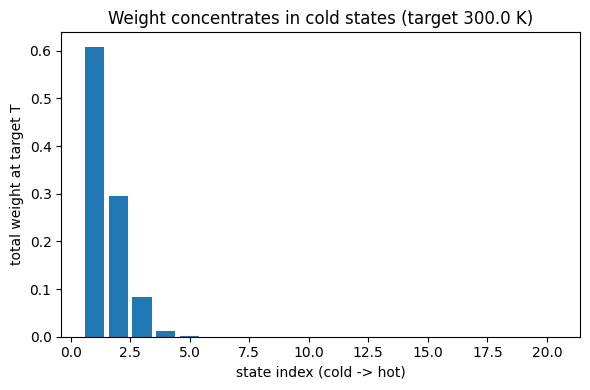

In [6]:
weights = result.weights   # (n_replica, n_step)
print(f"weights shape : {weights.shape}")
print(f"total sum     : {weights.sum():.6f}  (should be ~1.0)")

# Weight mass carried by each temperature state.
state_mass = weights.sum(axis=1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, NREPLICA + 1), state_mass)
ax.set_xlabel("state index (cold -> hot)")
ax.set_ylabel("total weight at target T")
ax.set_title(f"Weight concentrates in cold states (target {TARGET_T} K)")
plt.tight_layout()
plt.show()

In [7]:
# The weights match the paper reference weight{k}.dat.
ref_w = np.stack([np.loadtxt(C.TREMD_WEIGHT_PATTERN.format(k))[:, 1]
                  for k in range(1, NREPLICA + 1)])
print(f"max |weight - reference| = {np.max(np.abs(weights - ref_w)):.2e}")

max |weight - reference| = 1.49e-15


## 4. 重みによる再重み付け Ramachandran PMF

トリアラニンの主鎖二面角 φ/ψ（ここでは参照 `.tor` を利用；`trj_analysis` でも算出可）に対し、**weight で重み付けした 2 次元ヒストグラム**から 300 K の自由エネルギー面（PMF）を作ります。

各 `.tor` の列は `index  phi  psi` で、`(state, step)` 順に連結すると weight と同じ並びになります。

In [8]:
phi_states, psi_states = [], []
for k in range(1, NREPLICA + 1):
    tor = np.loadtxt(C.TREMD_TOR_PATTERN.format(k))
    phi_states.append(tor[:, 1])
    psi_states.append(tor[:, 2])
phi = np.concatenate(phi_states)   # (N,)
psi = np.concatenate(psi_states)   # (N,)
w_flat = weights.ravel()
w_flat = w_flat / w_flat.sum()
print(f"total samples: {phi.size}")

total samples: 100000


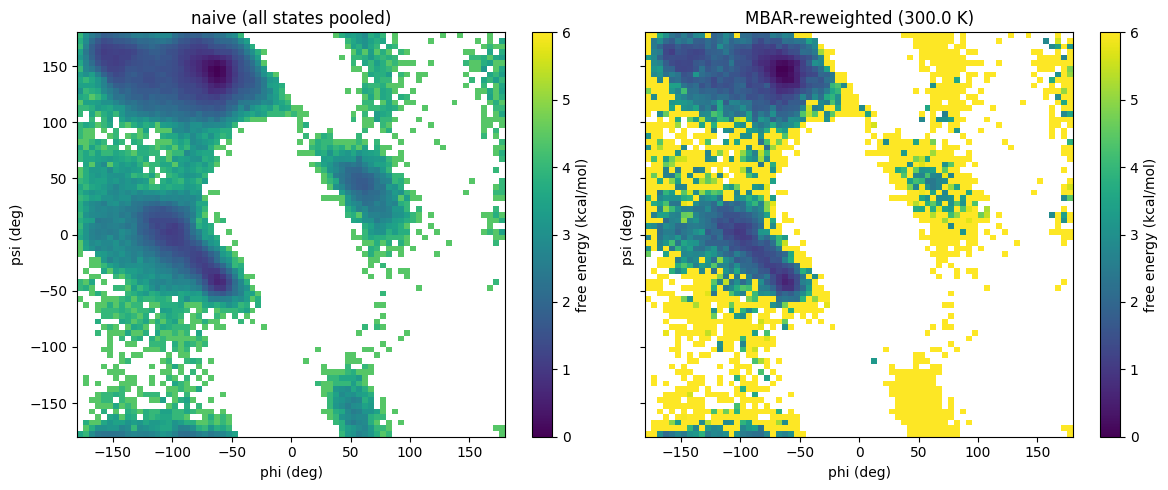

In [9]:
KB = 0.0019872041  # kcal/mol/K
bins = np.linspace(-180, 180, 73)

def pmf_2d(phi, psi, weights=None):
    H, xe, ye = np.histogram2d(phi, psi, bins=[bins, bins], weights=weights)
    P = H / H.sum()
    with np.errstate(divide="ignore"):
        F = -KB * TARGET_T * np.log(P)
    F -= np.nanmin(F[np.isfinite(F)])
    return np.ma.masked_invalid(F), xe, ye

# Naive (unweighted) histogram vs weight-reweighted PMF.
F_naive, xe, ye = pmf_2d(phi, psi)
F_reweighted, _, _ = pmf_2d(phi, psi, weights=w_flat)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, F, title in [(axes[0], F_naive, "naive (all states pooled)"),
                     (axes[1], F_reweighted, f"MBAR-reweighted ({TARGET_T} K)")]:
    pc = ax.pcolormesh(xe, ye, F.T, cmap="viridis", vmin=0, vmax=6)
    ax.set_xlabel("phi (deg)"); ax.set_ylabel("psi (deg)"); ax.set_title(title)
    fig.colorbar(pc, ax=ax, label="free energy (kcal/mol)")
plt.tight_layout()
plt.show()

## 5. リサンプリング

重み `w` に従ってフレームを**重複ありで抽出**すると、uniform weight のトラジェクトリが得られます。`mbar_resample_trajectory` は、MBAR → DCD ロード → リサンプリング → （任意で）DCD 保存を一括で行います。

In [10]:
import os, tempfile

dcd_files = [C.TREMD_DCD_PATTERN.format(k) for k in range(1, NREPLICA + 1)]
out_dir = tempfile.mkdtemp(prefix="mbar_resample_")
out_dcd = os.path.join(out_dir, "resampled_300K.dcd")

res = genesis_exe.mbar_resample_trajectory(
    molecule=mol,
    dcd_files=dcd_files,
    cvfile=C.TREMD_POT_PATTERN,
    nreplica=NREPLICA,
    temperature=TEMPERATURES,
    target_temperature=TARGET_T,
    input_type="EneSingle",
    self_iteration=100,
    newton_iteration=10,
    selection="all",       # DCD はすでに溶質のみ
    n_samples=phi.size,    # 総サンプル数と同数抽出
    seed=2024,
    output_dcd=out_dcd,
    isolated=True,
)

print(f"resampled frames: {res.trajectory.nframe}")
print(f"atoms per frame : {res.trajectory.natom}")
print(f"saved DCD       : {out_dcd}  ({os.path.getsize(out_dcd)/1e6:.2f} MB)")

resampled frames: 100000
atoms per frame : 42
saved DCD       : /var/folders/sq/vqh82prn4d9g1z4dx7xsdds00000gn/T/mbar_resample_besev2v7/resampled_300K.dcd  (52.80 MB)


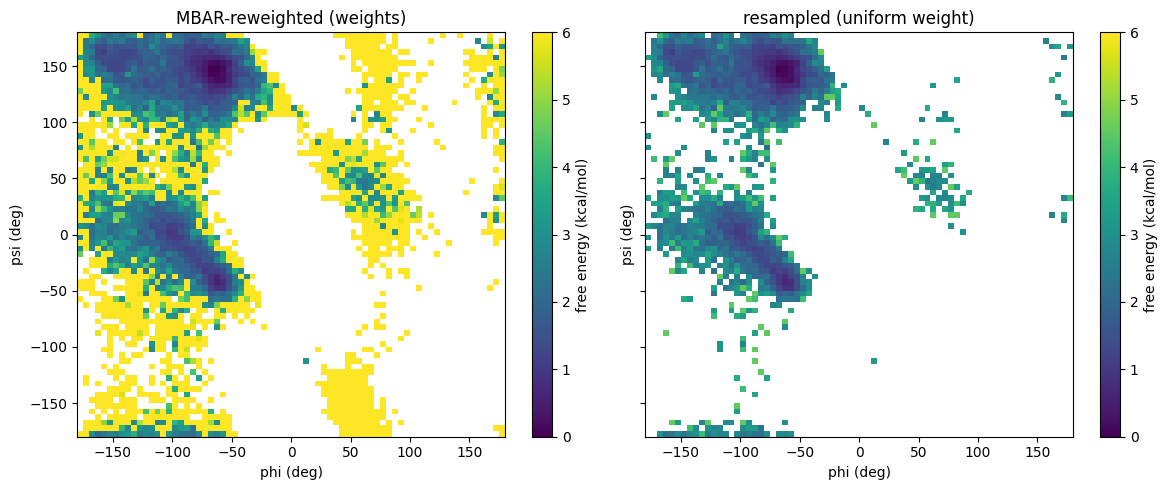

max |reweighted - resampled| (phi hist) = 0.0016


In [11]:
# The resampled ensemble's PLAIN histogram must reproduce the reweighted PMF.
# res.indices are indices into the same (state, step) order as phi/psi.
idx = res.indices
F_resampled, _, _ = pmf_2d(phi[idx], psi[idx])   # no weights: uniform now

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, F, title in [(axes[0], F_reweighted, "MBAR-reweighted (weights)"),
                     (axes[1], F_resampled, "resampled (uniform weight)")]:
    pc = ax.pcolormesh(xe, ye, F.T, cmap="viridis", vmin=0, vmax=6)
    ax.set_xlabel("phi (deg)"); ax.set_ylabel("psi (deg)"); ax.set_title(title)
    fig.colorbar(pc, ax=ax, label="free energy (kcal/mol)")
plt.tight_layout()
plt.show()

# Quantitative check on the 1-D phi distribution.
coarse = np.linspace(-180, 180, 19)
h_rw, _ = np.histogram(phi, bins=coarse, weights=w_flat)
h_rs, _ = np.histogram(phi[idx], bins=coarse); h_rs = h_rs / h_rs.sum()
print(f"max |reweighted - resampled| (phi hist) = {np.max(np.abs(h_rw - h_rs)):.4f}")

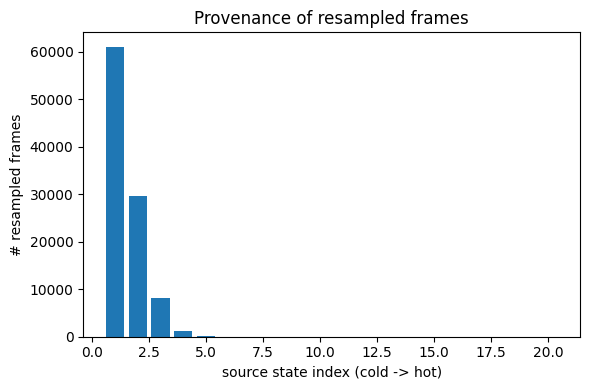

In [12]:
# Which states did the draws come from? Cold states dominate at 300 K.
state_of_draw = res.indices // res.weights.shape[1]
counts = np.bincount(state_of_draw, minlength=NREPLICA)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, NREPLICA + 1), counts)
ax.set_xlabel("source state index (cold -> hot)")
ax.set_ylabel("# resampled frames")
ax.set_title("Provenance of resampled frames")
plt.tight_layout()
plt.show()

## 6. 保存・応用

生成した DCD（`resampled_300K.dcd`）とトポロジー `trialanine.pdb` は、**単一アンサンブルの通常トラジェクトリ**として扱えます。mdtraj / MDAnalysis での解析、クラスタリング、または MDDB などの登録パイプラインへそのまま接続できます。

**まとめ**
- MBAR は多状態サンプリングを目標温度の per-sample weight に変換する。
- weight に従った重複ありリサンプリングで、uniform-weight の単一アンサンブル軌道が得られる。
- その素のヒストグラムは、weight で再重み付けした PMF を再現する—これがリサンプリングの正しさの確認。

In [13]:
import mdtraj

t = mdtraj.load(out_dcd, top=str(C.TREMD_PDB))
print(t)

<mdtraj.Trajectory with 100000 frames, 42 atoms, 3 residues, without unitcells>
